In [19]:
! pip install datasets

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


# Task 1: Language model inference

The goal if this first task is to familiarize yourself with the huggingface transformers and dataset libraries. You will learn how to load and tokenize a dataset, how to load a pre-trained language model, and finally, how to run a model in inference mode.

Your task is to complete the missing code blocks below.

In [20]:
# import dependencies
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

from datasets import load_dataset, load_dataset_builder, get_dataset_split_names, get_dataset_config_names
from transformers import XGLMTokenizer, XGLMTokenizerFast, XGLMForCausalLM, AutoModelForCausalLM, AutoTokenizer, GenerationConfig

In [12]:
print(torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))

# Check if CUDA (GPU support) is available
if torch.cuda.is_available():
    print("CUDA (GPU support) is available and enabled!")
    default_device = torch.device("cuda") # Set the device to GPU 1
else:
    print("CUDA (GPU support) is not available. Using CPU.")
    default_device = torch.device("cpu")

print(default_device)

0
CUDA (GPU support) is not available. Using CPU.
cpu


## Explore dataset

In [22]:
DATA_SET_NAME = "facebook/flores" # specify dataset name
MODEL_NAME = "facebook/xglm-564M" # specify model name
# MODEL_NAME = "gpt2" # specify model name

In [23]:
# Explore a dataset

# covered language codes can be found here: https://github.com/openlanguagedata/flores?tab=readme-ov-file#language-coverage

ds_builder = load_dataset_builder("facebook/flores", "deu_Latn")
print(ds_builder.info.description) # print the dataset description

/Users/nischalmaharjan/anaconda3/envs/nnti/lib/python3.11/site-packages/datasets/load.py:1454: FutureWarning: The repository for facebook/flores contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/facebook/flores
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


The creation of FLORES-200 doubles the existing language coverage of FLORES-101. 
Given the nature of the new languages, which have less standardization and require 
more specialized professional translations, the verification process became more complex. 
This required modifications to the translation workflow. FLORES-200 has several languages 
which were not translated from English. Specifically, several languages were translated 
from Spanish, French, Russian and Modern Standard Arabic. Moreover, FLORES-200 also 
includes two script alternatives for four languages. FLORES-200 consists of translations 
from 842 distinct web articles, totaling 3001 sentences. These sentences are divided 
into three splits: dev, devtest, and test (hidden). On average, sentences are approximately 
21 words long.



In [24]:
# print the features (columns) of the dataset
# TODO: your code goes here
print(ds_builder.info.features)

{'id': Value(dtype='int32', id=None), 'URL': Value(dtype='string', id=None), 'domain': Value(dtype='string', id=None), 'topic': Value(dtype='string', id=None), 'has_image': Value(dtype='int32', id=None), 'has_hyperlink': Value(dtype='int32', id=None), 'sentence': Value(dtype='string', id=None)}


In [25]:
# get the available splits
# TODO: your code goes here
#print(ds_builder.keys())


## Load data, tokenize, and batchify

In [26]:
# specify languages
LANGUAGES = [
    "eng_Latn",
    "spa_Latn",
    "ita_Latn",
    "deu_Latn",
    "arb_Arab",
    "tel_Telu",
    "tam_Taml",
    "quy_Latn"
]

In [27]:
# load flores data for each language
# TODO: your code goes here
dataset = []
for language in LANGUAGES:
    dataset.append(load_dataset("facebook/flores", language, trust_remote_code=True))

In [28]:
# let's look at the English subset
# TODO: your code goes here
eng = dataset[0]
print(eng)

DatasetDict({
    dev: Dataset({
        features: ['id', 'URL', 'domain', 'topic', 'has_image', 'has_hyperlink', 'sentence'],
        num_rows: 997
    })
    devtest: Dataset({
        features: ['id', 'URL', 'domain', 'topic', 'has_image', 'has_hyperlink', 'sentence'],
        num_rows: 1012
    })
})


In [29]:
# let's look at an individal sample from the dataset
# TODO: your code goes here

# check the first sample from the dev set
print(eng["dev"][0])

# check the first sample from the devtest set
print(eng["devtest"][0])

{'id': 1, 'URL': 'https://en.wikinews.org/wiki/Scientists_say_new_medical_diagnostic_chip_can_sort_cells_anywhere_with_an_inkjet', 'domain': 'wikinews', 'topic': 'health', 'has_image': 0, 'has_hyperlink': 0, 'sentence': 'On Monday, scientists from the Stanford University School of Medicine announced the invention of a new diagnostic tool that can sort cells by type: a tiny printable chip that can be manufactured using standard inkjet printers for possibly about one U.S. cent each.'}
{'id': 1, 'URL': 'https://en.wikinews.org/wiki/Toronto_team-led_research_on_Type_1_Diabetes_%27groundbreaking%27', 'domain': 'wikinews', 'topic': 'disease, research, canada', 'has_image': 0, 'has_hyperlink': 0, 'sentence': '"We now have 4-month-old mice that are non-diabetic that used to be diabetic," he added.'}


In [30]:
# tokenize the data
# The model is either facebook/xglm-564M or gpt2.

# load a pre-trained tokenizer from the huggingface hub

print("Model name: ", MODEL_NAME)
# The from_pretrained() method takes care of returning the correct tokenizer class instance based on the model_type property
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# since we are using a decoder only architecture, we need to perform the padding
# on the left side so that the model does not get confused while guessing the next token.
tokenizer.padding_side = 'left'

print(tokenizer)

# gpt2 does not have a padding token, so we have to add it manually
if MODEL_NAME == "gpt2":
    tokenizer.add_special_tokens({'pad_token': tokenizer.unk_token})

#tokenizer.config.output_attentions

# specify the tokenization function
def tokenization(example):
    # fill in here
    tokenized = tokenizer(example)
    return tokenized

# TODO: your code goes here
first_sentence = eng["devtest"][0]["sentence"]
print(first_sentence)
tokenized_sentence = tokenization(first_sentence)

Model name:  facebook/xglm-564M
XGLMTokenizerFast(name_or_path='facebook/xglm-564M', vocab_size=256008, model_max_length=2048, is_fast=True, padding_side='left', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'additional_special_tokens': ['<madeupword0>', '<madeupword1>', '<madeupword2>', '<madeupword3>', '<madeupword4>', '<madeupword5>', '<madeupword6>']}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	256001: AddedToken("<madeupword0>", rstrip=Fal

In [31]:
# let's take a look at a tokenized sample
# TODO: your code goes here

In [32]:
# construct a pytorch data loader for each dataset
BATCH_SIZE = 2 # for testing purposes, we start with a batch size of 2. You can change this later.

# TODO: your code goes here
# I assume that each language is making up a dataset.

# Create a dictionary of DataLoaders for each language and split
data_loaders = {
    lang: {
        "dev": DataLoader(lang_dataset["dev"], batch_size=BATCH_SIZE, shuffle=True),
        "devtest": DataLoader(lang_dataset["devtest"], batch_size=BATCH_SIZE, shuffle=True)
    } for lang, lang_dataset in zip(LANGUAGES, dataset)
}


## Load model

In [15]:
# load pre-trained model from the huggingface hub
print(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
# put the model into evaluation mode
# TODO: your code goes here

facebook/xglm-564M


config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

In [16]:
model.eval().to(default_device)

XGLMForCausalLM(
  (model): XGLMModel(
    (embed_tokens): Embedding(256008, 1024, padding_idx=1)
    (embed_positions): XGLMSinusoidalPositionalEmbedding()
    (layers): ModuleList(
      (0-23): 24 x XGLMDecoderLayer(
        (self_attn): XGLMAttention(
          (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (activation_fn): GELUActivation()
        (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (final_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      )
    )
    (layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine

In [17]:
losses = {lang: [] for lang in LANGUAGES} # store per-batch losses for each language

# iterate over the dataset for each language and compute the cross-entropy loss per batch
# TODO: your code goes here

# check if the current model is capable of generating new tokens.
print(model.can_generate())


embeddings = []

# no need to calculate the gradients since we are only evaluating
with torch.no_grad():
    # Find the loss for every language individually.
    for lang in LANGUAGES:
        # Find the loss based on dev set
        current_loader = data_loaders[lang]["dev"]

        # set the loss to zero initially
        loss = 0
        print(lang)
        # iterate over the batches and find the loss per batch
        lang_embeddings = torch.zeros((0,25,1024)).to(default_device)
        for i in range(len(current_loader)):
            # since batch size = 2, we can get 2 new instances from the dataset.
            sentences = next(iter(current_loader))["sentence"]

            # encode the sentence (without the last word)
            encoded_sentences = tokenizer(sentences, padding=True, truncation=True, return_tensors="pt")

            # get the input ids
            input_ids = encoded_sentences["input_ids"].to(default_device)

            # attention mask either holds a value of 0 or 1 depending on
            # if the token is a padded one or not.
            attention_mask = encoded_sentences["attention_mask"]

            # we need to put a label of -100 for the padded parts
            labels = input_ids.clone().to(default_device)
            labels[attention_mask == 0] = -100

            # pass the input ids and labels to the model
            generated_output = model(input_ids=input_ids, attention_mask = attention_mask, labels=labels, output_hidden_states= True)

            # get the embedding
            hidden_states = generated_output.hidden_states #(25*(batch_size, num_token, 1024))
            concatenated_hidden_states = torch.stack(hidden_states, dim =2)
            num_tokens = concatenated_hidden_states.size(1)
            batch_size = concatenated_hidden_states.size(0)
            flattened_hidden_states = concatenated_hidden_states.view(batch_size * num_tokens, 25, 1024)
            # print(flattened_hidden_states.shape)
            lang_embeddings = torch.concat((lang_embeddings,flattened_hidden_states), dim =0)

            if i >100:
                break

        embeddings.append(lang_embeddings)


True
eng_Latn
spa_Latn
ita_Latn
deu_Latn
arb_Arab
tel_Telu
tam_Taml
quy_Latn


In [18]:
for each in embeddings:
    print(each.shape)

torch.Size([6694, 25, 1024])
torch.Size([8674, 25, 1024])
torch.Size([8376, 25, 1024])
torch.Size([8160, 25, 1024])
torch.Size([8706, 25, 1024])
torch.Size([10220, 25, 1024])
torch.Size([10334, 25, 1024])
torch.Size([9934, 25, 1024])


In [34]:
import pickle

In [35]:

with open('embeddings.pkl', 'wb') as f:
    pickle.dump(embeddings, f)

In [7]:
import h5py
import pickle
import torch

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [8]:
with open('embeddings.pkl', 'rb') as f:
    embeddings = pickle.load(f)

In [9]:
layer_embeddings = embeddings[0][:, 0, :]

In [10]:
layer_embeddings.shape

torch.Size([6694, 1024])

In [19]:
layer_data_embedding = torch.zeros(0, 1024).to(default_device)
for i, e_embeddings in enumerate(embeddings):
    # Perform t-SNE
    layer_embeddings = e_embeddings[:,0,:]
    layer_data_embedding = torch.cat((layer_data_embedding,layer_embeddings), dim=0)


layer_data_embedding = layer_data_embedding.cpu().numpy()
pca = PCA(n_components=2)  # Assuming you want to reduce to 2 dimensions for visualization
pca_result = pca.fit_transform(layer_data_embedding)

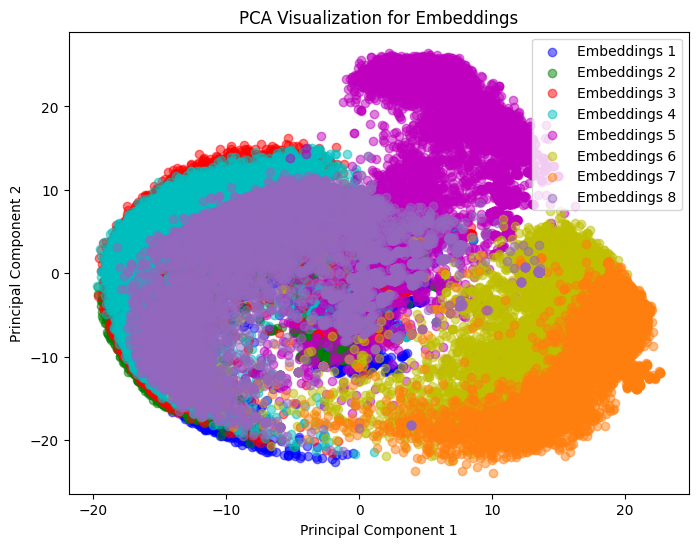

In [16]:
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'tab:orange', 'tab:purple']

# Visualize the results with a different color for each set of embeddings
plt.figure(figsize=(8, 6))
curr_idx = 0
for i, e_embeddings in enumerate(embeddings):
    n_class = len(e_embeddings[:,-1,:])
    plt.scatter(pca_result[curr_idx:curr_idx+n_class, 0], pca_result[curr_idx:curr_idx+n_class, 1], color=colors[i], alpha=0.5,
            label=f'Embeddings {i+1}')
    # plt.show()
    curr_idx += n_class
    # print(tsne_result)
plt.title(f'PCA Visualization for Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

In [ ]:
layer_data_embedding = torch.zeros(0, 1024).to(default_device)
for i, e_embeddings in enumerate(embeddings):
    # Perform t-SNE
    layer_embeddings = e_embeddings[:,0,:]
    layer_data_embedding = torch.cat((layer_data_embedding,layer_embeddings), dim=0)


layer_data_embedding = layer_data_embedding.cpu().numpy()
pca = PCA(n_components=3)  # Assuming you want to reduce to 3 dimensions for visualization
pca_result = pca.fit_transform(layer_data_embedding)

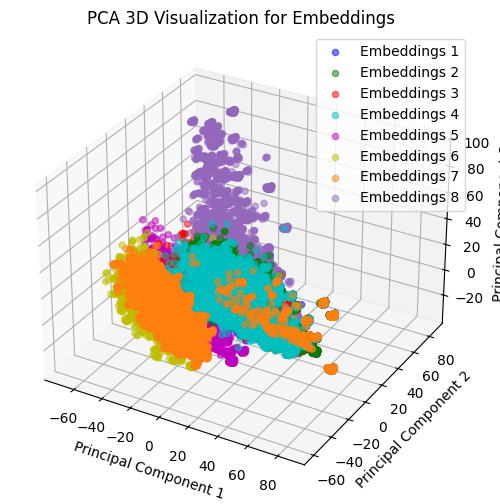

In [20]:
from mpl_toolkits.mplot3d import Axes3D

# Visualize the results in 3D with a different color for each set of embeddings
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
curr_idx = 0
for i, e_embeddings in enumerate(embeddings):
     n_class = len(e_embeddings[:,0,:])
     ax.scatter(pca_result[curr_idx:curr_idx+n_class, 0], pca_result[curr_idx:curr_idx+n_class, 1], pca_result[curr_idx:curr_idx+n_class, 2], color=colors[i], alpha=0.5,
                label=f'Embeddings {i+1}')
     curr_idx += n_class
ax.set_title('PCA 3D Visualization for Embeddings')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.legend()
plt.show()

In [ ]:
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'tab:orange', 'tab:purple']

layer_data_embedding = torch.zeros(0, 1024).to(default_device)
for i, e_embeddings in enumerate(embeddings):
    # Perform t-SNE
    layer_embeddings = e_embeddings[:,19,:]
    layer_data_embedding = torch.cat((layer_data_embedding,layer_embeddings), dim=0)

layer_data_embedding = layer_data_embedding.cpu().numpy()
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(layer_data_embedding)

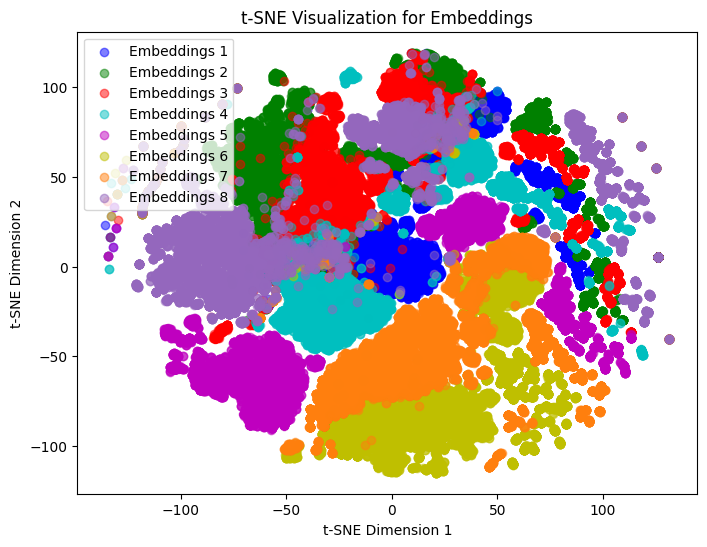

In [54]:
# Visualize the results with a different color for each set of embeddings
plt.figure(figsize=(8, 6))
curr_idx = 0
for i, e_embeddings in enumerate(embeddings):
    n_class = len(e_embeddings[:,0,:])
    plt.scatter(tsne_result[curr_idx:curr_idx+n_class, 0], tsne_result[curr_idx:curr_idx+n_class, 1], color=colors[i], alpha=0.5,
            label=f'Embeddings {i+1}')
    curr_idx += n_class
    # print(tsne_result)
plt.title('t-SNE Visualization for Embeddings')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.show()

In [ ]:
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'tab:orange', 'tab:purple']

layer_data_embedding = torch.zeros(0, 1024).to(default_device)
for i, e_embeddings in enumerate(embeddings):
    # Perform t-SNE
    layer_embeddings = e_embeddings[:,19,:]
    layer_data_embedding = torch.cat((layer_data_embedding,layer_embeddings), dim=0)

layer_data_embedding = layer_data_embedding.cpu().numpy()
tsne = TSNE(n_components=3, random_state=42)
tsne_result = tsne.fit_transform(layer_data_embedding)

IndexError: index 2 is out of bounds for axis 1 with size 2

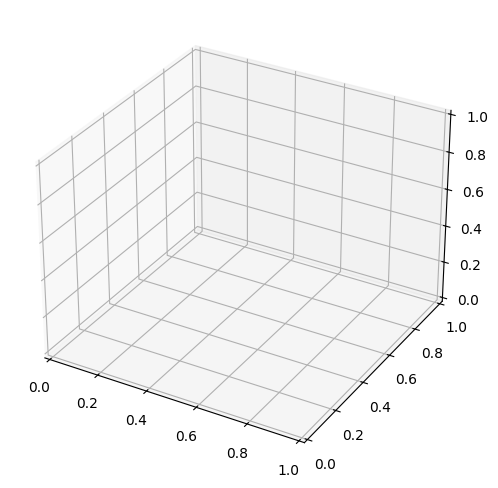

In [53]:
from mpl_toolkits.mplot3d import Axes3D

    # Visualize the results in 3D with a different color for each set of embeddings
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
curr_idx = 0
for i, e_embeddings in enumerate(embeddings):
     n_class = len(e_embeddings[:,0,:])
     ax.scatter(tsne_result[curr_idx:curr_idx+n_class, 0], tsne_result[curr_idx:curr_idx+n_class, 1], tsne_result[curr_idx:curr_idx+n_class, 2], color=colors[i], alpha=0.5,
                label=f'Embeddings {i+1}')
     curr_idx += n_class
ax.set_title('t-SNE 3D Visualization for Embeddings')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.set_zlabel('t-SNE Dimension 3')
ax.legend()
plt.show()

100*[2,n_token, 1024] -> each language
[total_token, 25, 1024] -> each langauge
8* [total_token, 25, 1024] -> separate colour

---
[all_tokens, 25, 1024] -> 1 st layer [:, 0, :]



In [ ]:
import pickle
with open('tsne_embd.pkl', 'wb') as f:
    pickle.dump(tsne_result, f)

In [ ]:
tsne_result.shape

(2746, 2)